<a href="https://colab.research.google.com/github/logansivam/Testing/blob/main/DMDW_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Warehousing (Loading & Merging)
This stage fulfills the Data Warehousing objective by integrating your automotive datasets (train.csv and devel.csv) into a single analysis corpus.**

In [1]:
import pandas as pd

# Load the MuSe-CarASTE automotive datasets
train_df = pd.read_csv('train.csv', encoding='latin1')
devel_df = pd.read_csv('devel.csv', encoding='latin1')

# Merge them to create a larger 'warehouse' for better topic modeling
warehouse_df = pd.concat([train_df, devel_df], ignore_index=True)

# Load the social media engagement dataset
engagement_df = pd.read_csv('sentimentdataset.csv', encoding='latin1')

print(f"Data Warehouse established with {len(warehouse_df)} automotive records.")

Data Warehouse established with 15722 automotive records.


**Data Preprocessing (ETL)
This script cleans the raw text by removing noise, which is essential for accurate Topic Modeling.**

In [2]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase and remove special characters/numbers
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    # 2. Tokenization and Stopword Removal
    tokens = [word for word in text.split() if word not in stop_words and len(word) > 2]
    return tokens

# Apply cleaning to the 'review' column
warehouse_df['cleaned_tokens'] = warehouse_df['review'].apply(preprocess_text)
warehouse_df['cleaned_text'] = warehouse_df['cleaned_tokens'].apply(lambda x: " ".join(x))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Sentiment Analysis (VADER)
Using the VADER model mentioned in your methodology to classify audience sentiment into Positive, Neutral, or Negative.**

In [3]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def get_vader_score(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

# Perform analysis on the automotive content
warehouse_df['predicted_sentiment'] = warehouse_df['cleaned_text'].apply(get_vader_score)

# Display results summary
print(warehouse_df['predicted_sentiment'].value_counts(normalize=True))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


predicted_sentiment
Positive    0.826803
Negative    0.091782
Neutral     0.081415
Name: proportion, dtype: float64


**Topic Modeling (LDA)
This implements Latent Dirichlet Allocation (LDA) to discover the recurring themes in car maintenance content.**

In [4]:
!pip install gensim
from gensim import corpora
from gensim.models.ldamodel import LdaModel

# Create Dictionary and Corpus
dictionary = corpora.Dictionary(warehouse_df['cleaned_tokens'])
corpus = [dictionary.doc2bow(text) for text in warehouse_df['cleaned_tokens']]

# Train LDA Model (Finding 5 major topics)
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes=15, random_state=42)

# Print the keywords for each identified theme
print("\n--- Identified Learning Themes ---")
for idx, topic in lda_model.print_topics(-1):
    print(f"Theme {idx}: {topic}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.7 MB/s eta 0:00:00

--- Identified Learning Themes ---
Theme 0: 0.023*"car" + 0.016*"like" + 0.013*"really" + 0.013*"think" + 0.011*"got" + 0.011*"audi" + 0.010*"new" + 0.010*"little" + 0.010*"one" + 0.009*"looks"
Theme 1: 0.021*"car" + 0.014*"want" + 0.013*"get" + 0.012*"right" + 0.011*"different" + 0.009*"set" + 0.009*"youre" + 0.009*"like" + 0.009*"put" + 0.008*"one"
Theme 2: 0.023*"car" + 0.018*"really" + 0.015*"like" + 0.014*"drive" + 0.013*"bit" + 0.011*"well" + 0.011*"suspension" + 0.011*"steering" + 0.010*"road" + 0.010*"little"
Theme 3: 0.029*"back" + 0.019*"got" + 0.014*"like" + 0.012*"bit" + 0.012*"theres" + 0.011*"well" + 0.011*"seats" + 0.011*"seat" + 0.011*"look" + 0.011*"room"
Theme 4: 0.017*"car" + 0.014*"engine" + 0.012*"get" + 0.011*"power" + 0.008*"thats" + 0.008*"drive" + 0.008*"turbo" + 0.007*"audi" + 0.007*"four" + 0.007*"really"


**Engagement Profiling
This code uses your sentimentdataset.csv to answer your research question regarding platform differences (TikTok vs. Instagram).**

/tmp/ipython-input-1662829563.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=engagement_summary.index, y=engagement_summary.values, palette='viridis')



Engagement chart saved as 'engagement_analysis.png'.


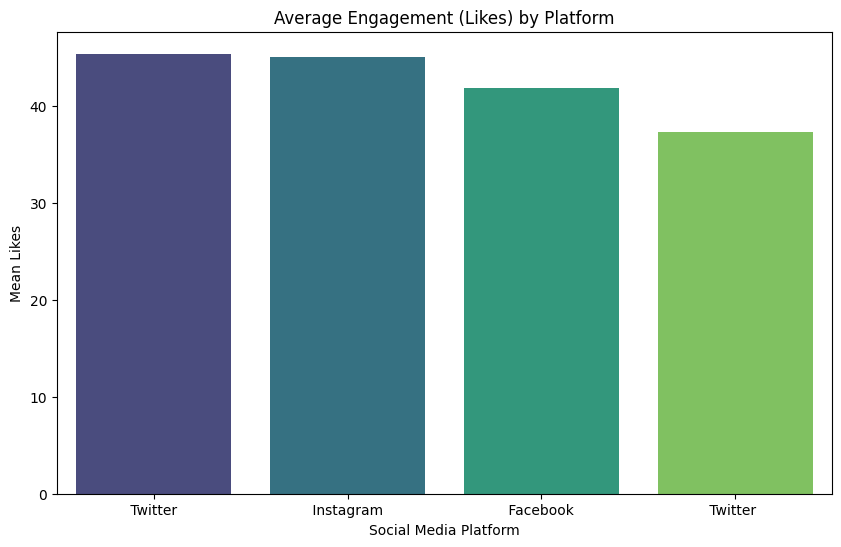

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average likes per platform
engagement_summary = engagement_df.groupby('Platform')['Likes'].mean().sort_values(ascending=False)

# Visualization for Slides
plt.figure(figsize=(10, 6))
sns.barplot(x=engagement_summary.index, y=engagement_summary.values, palette='viridis')
plt.title('Average Engagement (Likes) by Platform')
plt.ylabel('Mean Likes')
plt.xlabel('Social Media Platform')
plt.savefig('engagement_analysis.png')
print("\nEngagement chart saved as 'engagement_analysis.png'.")